# 02 — EDA

**Input:** `data/processed/sfu_clean.db` — table: `offerings`  
**Purpose:** Validate that raw signals exist before engineering features. One EDA serves all three models.

| Block | What we check |
|-------|---------------|
| 1 | Dataset overview — shape, dtypes, duplicates, sections per term |
| 2 | Target distributions — capacity, enrolled, fill_rate |
| 3 | Feature signal validation — course_level, degree_level, units, prereq_count, term_order |
| 4 | Sparsity — how many terms does a typical course appear in? |
| 5 | Temporal patterns — COVID effect, year-over-year trends |
| 6 | Categorical check — dept_code cardinality and encoding strategy |

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DB_PATH  = Path('../data/processed/sfu_clean.db')
FIG_PATH = Path('../figures/02_eda')
FIG_PATH.mkdir(parents=True, exist_ok=True)

assert DB_PATH.exists(), f'not found: {DB_PATH}'
print('ready')

ready


In [2]:
conn = sqlite3.connect(DB_PATH)
df   = pd.read_sql('SELECT * FROM offerings', conn)
conn.close()

# derived column used throughout
df['fill_rate'] = df['enrolled'] / df['capacity']

print(f'{len(df):,} rows  x  {df.shape[1]} cols')

33,659 rows  x  21 cols


---
## Block 1 — Dataset overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33659 entries, 0 to 33658
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   offering_id        33659 non-null  int64  
 1   ml_course_id       33659 non-null  int64  
 2   ml_term_id         33659 non-null  int64  
 3   dept_code          33659 non-null  object 
 4   course_number      33659 non-null  object 
 5   section_code       33659 non-null  object 
 6   instructor         28916 non-null  object 
 7   campus             33659 non-null  object 
 8   capacity           33659 non-null  int64  
 9   enrolled           33659 non-null  int64  
 10  course_level       33659 non-null  int64  
 11  degree_level       33659 non-null  object 
 12  units              33659 non-null  int64  
 13  prereq_count       33659 non-null  int64  
 14  title              33659 non-null  object 
 15  year               33659 non-null  int64  
 16  term               336

In [4]:
# exact duplicates
print(f'exact duplicates:   {df.duplicated().sum()}')
# logical duplicates — same course, same term, same section
print(f'logical duplicates: {df.duplicated(subset=["ml_course_id", "ml_term_id", "section_code"]).sum()}')

exact duplicates:   0
logical duplicates: 0


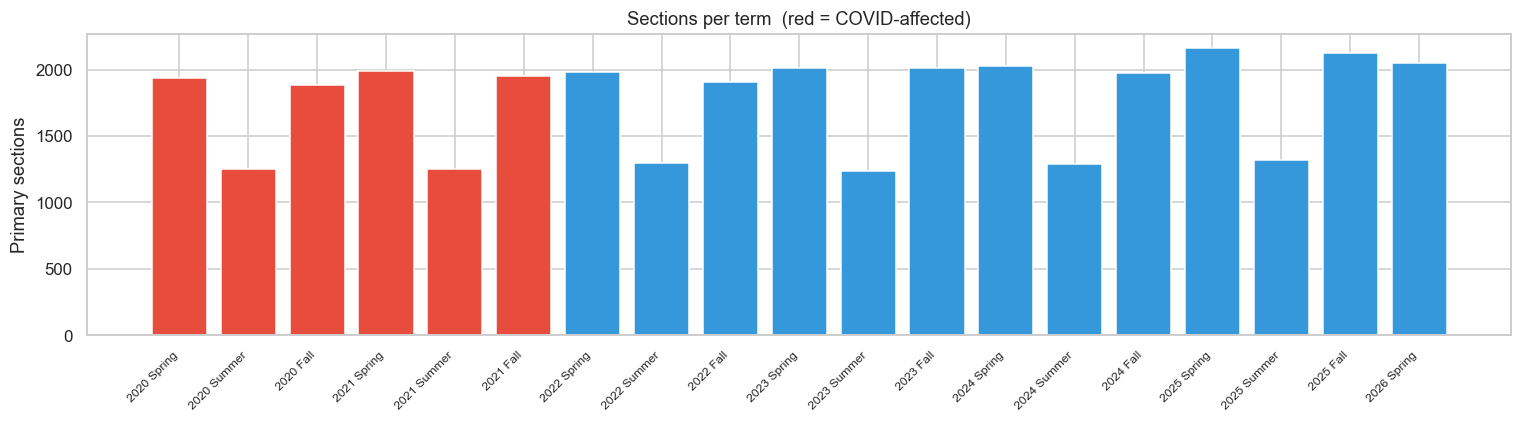

      label  n_sections  is_covid_affected
2020 Spring        1934                  1
2020 Summer        1250                  1
  2020 Fall        1886                  1
2021 Spring        1990                  1
2021 Summer        1251                  1
  2021 Fall        1950                  1
2022 Spring        1985                  0
2022 Summer        1295                  0
  2022 Fall        1905                  0
2023 Spring        2010                  0
2023 Summer        1239                  0
  2023 Fall        2016                  0
2024 Spring        2026                  0
2024 Summer        1288                  0
  2024 Fall        1977                  0
2025 Spring        2162                  0
2025 Summer        1320                  0
  2025 Fall        2127                  0
2026 Spring        2048                  0


In [5]:
# sections per term — expect summer dip, stable fall/spring
by_term = (
    df.groupby(['year', 'term_order', 'term', 'is_covid_affected'])
    .size()
    .reset_index(name='n_sections')
    .sort_values(['year', 'term_order'])
)
by_term['label'] = by_term['year'].astype(str) + ' ' + by_term['term'].str.capitalize()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#e74c3c' if c else '#3498db' for c in by_term['is_covid_affected']]
ax.bar(range(len(by_term)), by_term['n_sections'], color=colors, edgecolor='white')
ax.set_xticks(range(len(by_term)))
ax.set_xticklabels(by_term['label'], rotation=45, ha='right', fontsize=8)
ax.set_title('Sections per term  (red = COVID-affected)')
ax.set_ylabel('Primary sections')
plt.tight_layout()
plt.savefig(FIG_PATH / '01_sections_per_term.png', dpi=150, bbox_inches='tight')
plt.show()
print(by_term[['label','n_sections','is_covid_affected']].to_string(index=False))

---
## Block 2 — Target distributions

`capacity` and `enrolled` are what we predict. `fill_rate` feeds into `high_fill_rate_frequency`.

In [6]:
df[['capacity', 'enrolled', 'fill_rate']].describe().T

,count,mean,std,min,25%,50%,75%,max
capacity,33659.000,50.554,63.203,1.000,12.000,30.000,60.000,812.000
enrolled,33659.000,36.466,53.284,1.000,4.000,18.000,42.000,606.000
fill_rate,33659.000,0.670,0.346,0.002,0.400,0.743,0.940,13.000


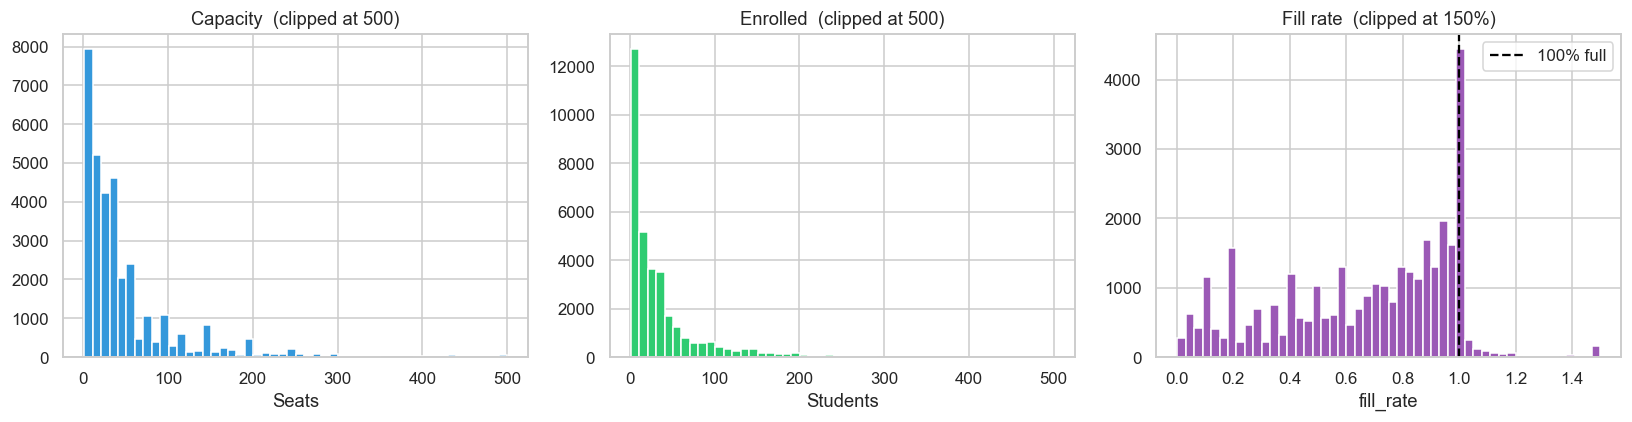

over-enrolled sections: 946  (2.8%)
mean fill rate:         0.670
median fill rate:       0.743


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['capacity'].clip(upper=500).hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Capacity  (clipped at 500)')
axes[0].set_xlabel('Seats')

df['enrolled'].clip(upper=500).hist(bins=50, ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Enrolled  (clipped at 500)')
axes[1].set_xlabel('Students')

df['fill_rate'].clip(upper=1.5).hist(bins=50, ax=axes[2], color='#9b59b6', edgecolor='white')
axes[2].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% full')
axes[2].set_title('Fill rate  (clipped at 150%)')
axes[2].set_xlabel('fill_rate')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_PATH / '02_target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

over = df[df['fill_rate'] > 1.0]
print(f'over-enrolled sections: {len(over):,}  ({len(over)/len(df)*100:.1f}%)')
print(f'mean fill rate:         {df["fill_rate"].mean():.3f}')
print(f'median fill rate:       {df["fill_rate"].median():.3f}')

In [8]:
# high fill rate frequency threshold check
# we define 'high fill rate' as fill_rate >= 0.9 — confirm this is a meaningful threshold
thresholds = [0.7, 0.8, 0.9, 0.95, 1.0]
for t in thresholds:
    n = (df['fill_rate'] >= t).sum()
    print(f'fill_rate >= {t:.2f}: {n:>6,}  ({n/len(df)*100:.1f}%)')

fill_rate >= 0.70: 18,354  (54.5%)
fill_rate >= 0.80: 15,252  (45.3%)
fill_rate >= 0.90: 10,677  (31.7%)
fill_rate >= 0.95:  7,730  (23.0%)
fill_rate >= 1.00:  5,233  (15.5%)


---
## Block 3 — Feature signal validation

For each raw feature: does it actually correlate with the targets? If no signal → drop the feature.

             capacity              enrolled              fill_rate         \
                 mean median count     mean median count      mean median   
course_level                                                                
100           120.000 81.000  3633   95.700 62.000  3633     0.800  0.800   
200            85.600 60.000  4231   66.300 45.000  4231     0.700  0.800   
300            59.300 40.000  7499   44.500 32.000  7499     0.700  0.800   
400            26.700 20.000  8294   17.300 12.000  8294     0.700  0.800   
500            34.700 30.000   464   20.200 16.000   464     0.600  0.600   
600            24.200 18.000  1165   14.500 10.000  1165     0.600  0.600   
700            37.000 35.000   966   22.500 18.000   966     0.600  0.600   
800            22.100 15.000  6345   10.500  5.000  6345     0.500  0.500   
900            15.900 15.000  1062    6.700  4.000  1062     0.500  0.400   

                    
             count  
course_level        
100         

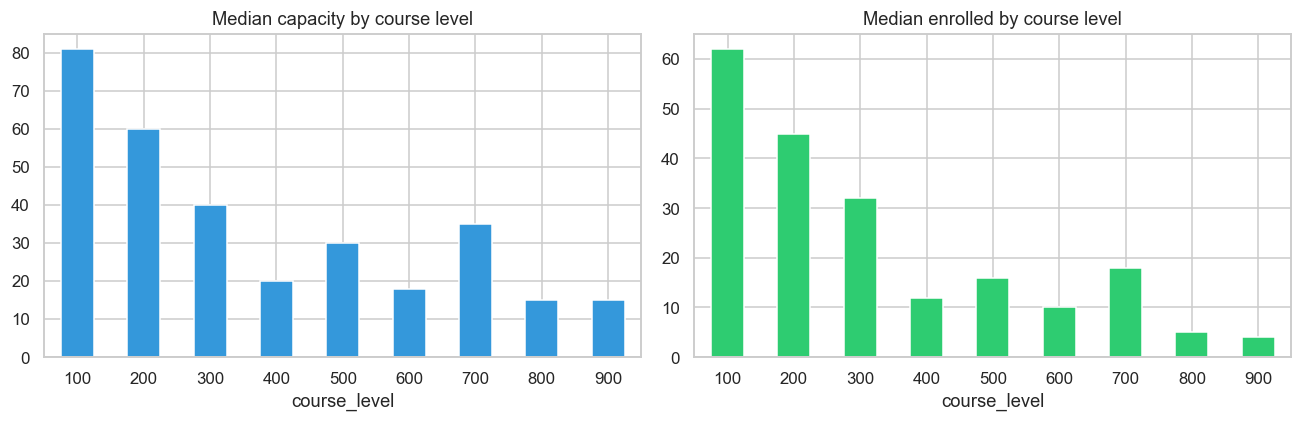

In [9]:
# 3a — course_level vs capacity and enrolled
# expectation: higher levels = smaller classes
level_stats = (
    df.groupby('course_level')[['capacity', 'enrolled', 'fill_rate']]
    .agg(['mean', 'median', 'count'])
    .round(1)
)
print(level_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['capacity', 'enrolled'], ['#3498db', '#2ecc71']):
    df.groupby('course_level')[col].median().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Median {col} by course level')
    ax.set_xlabel('course_level')
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_PATH / '03_course_level_signal.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 3b — degree_level vs capacity and enrolled
# expectation: GRAD courses much smaller than UGRD
print(df.groupby('degree_level')[['capacity', 'enrolled', 'fill_rate']].agg(['mean', 'median', 'count']).round(1))

             capacity               enrolled               fill_rate         \
                 mean median  count     mean median  count      mean median   
degree_level                                                                  
GRAD           23.700 16.000  10002   12.200  6.000  10002     0.500  0.500   
UGRD           61.900 35.000  23657   46.700 28.000  23657     0.700  0.800   

                     
              count  
degree_level         
GRAD          10002  
UGRD          23657  


      capacity               enrolled               fill_rate              
          mean median  count     mean median  count      mean median  count
units                                                                      
1       22.200  6.000    567   12.800  2.000    567     0.800  0.800    567
2       53.000 40.000    693   36.100 23.000    693     0.600  0.600    693
3       61.000 35.000  19830   44.600 24.000  19830     0.700  0.800  19830
4       47.700 35.000   6423   37.600 25.000   6423     0.800  0.800   6423
5       13.500 12.000   2149    7.600  4.000   2149     0.600  0.600   2149
6       16.400 10.000    943    8.600  3.000    943     0.600  0.500    943
7       30.200 34.000    126   25.400 31.000    126     0.800  0.900    126
8       28.700 34.000    113   25.300 32.000    113     1.000  0.900    113
9       10.100 10.000     96    4.500  3.000     96     0.500  0.400     96
10      12.600 10.000    197    5.300  1.000    197     0.500  0.400    197
12      22.1

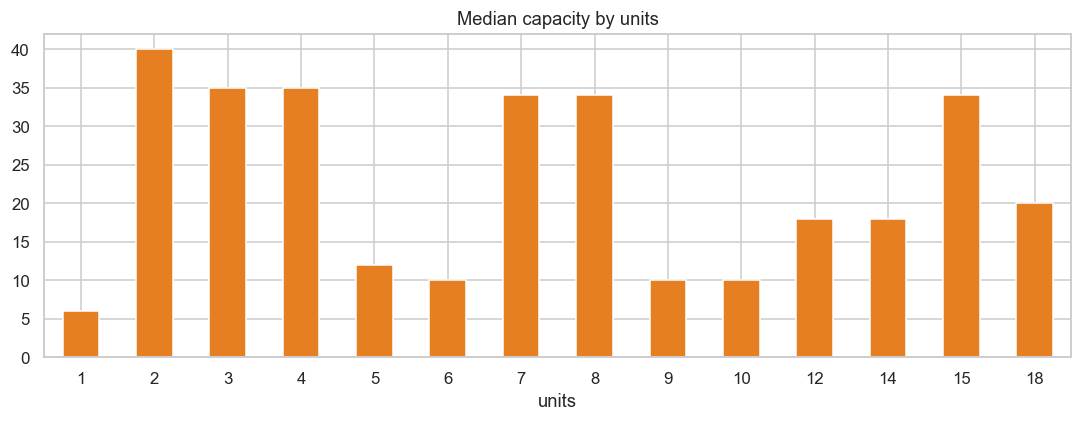

In [11]:
# 3c — units vs capacity and enrolled
# expectation: 1-unit labs/seminars have different dynamics than 3-unit courses
print(df.groupby('units')[['capacity', 'enrolled', 'fill_rate']].agg(['mean', 'median', 'count']).round(1))

fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('units')['capacity'].median().plot(kind='bar', ax=ax, color='#e67e22', edgecolor='white')
ax.set_title('Median capacity by units')
ax.set_xlabel('units')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_PATH / '04_units_signal.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# 3d — prereq_count vs enrolled
# expectation: more prereqs = more filtered/advanced students = different enrollment pattern
print(df['prereq_count'].value_counts().sort_index())
print()
print(df.groupby('prereq_count')[['enrolled', 'fill_rate']].agg(['mean', 'median', 'count']).round(2))

prereq_count
0     11214
1     12422
2      3928
3      2056
4      1672
5       922
6       534
7       342
8       161
9       115
10       45
11       49
12       13
13        7
16      158
18       21
Name: count, dtype: int64

             enrolled                fill_rate              
                 mean  median  count      mean median  count
prereq_count                                                
0              32.020  12.000  11214     0.620  0.660  11214
1              32.270  17.000  12422     0.670  0.750  12422
2              43.080  24.000   3928     0.700  0.800   3928
3              50.110  29.000   2056     0.740  0.790   2056
4              48.890  30.000   1672     0.690  0.770   1672
5              53.160  29.000    922     0.720  0.750    922
6              31.730  29.000    534     0.730  0.800    534
7              58.330  45.000    342     0.910  0.960    342
8              47.260  19.000    161     0.740  0.840    161
9              33.300  33.000    115

                  capacity        enrolled        fill_rate       
                      mean median     mean median      mean median
term_order term                                                   
1          spring   50.100 30.000   36.600 18.000     0.700  0.800
2          summer   46.100 30.000   30.600 16.000     0.600  0.700
3          fall     53.900 30.000   40.100 19.000     0.700  0.800


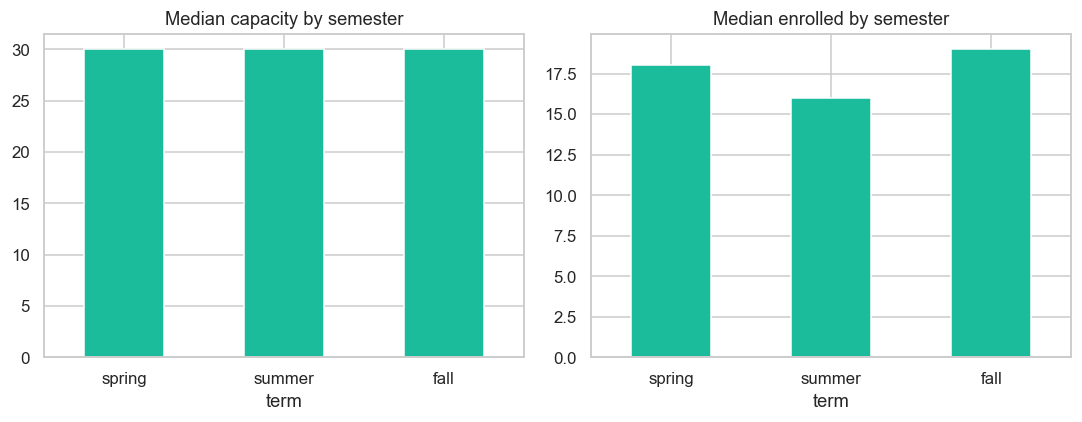

In [13]:
# 3e — term_order seasonality
# expectation: summer (term_order=2) has smaller classes
term_stats = df.groupby(['term_order', 'term'])[['capacity', 'enrolled', 'fill_rate']].agg(['mean', 'median']).round(1)
print(term_stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['capacity', 'enrolled']):
    df.groupby('term')[col].median().reindex(['spring', 'summer', 'fall']).plot(
        kind='bar', ax=ax, color='#1abc9c', edgecolor='white'
    )
    ax.set_title(f'Median {col} by semester')
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_PATH / '05_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

Pearson correlations — raw features vs targets
                   capacity  enrolled  fill_rate
course_level         -0.415    -0.433     -0.252
units                -0.122    -0.152     -0.136
prereq_count          0.073     0.098      0.132
term_order            0.024     0.027     -0.015
is_covid_affected     0.018     0.025      0.013


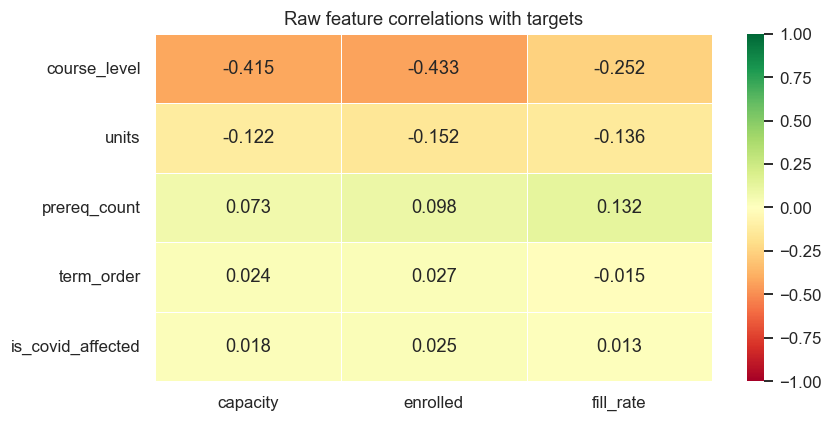

In [14]:
# 3f — Pearson correlation summary for all raw numeric features vs targets
raw_features = ['course_level', 'units', 'prereq_count', 'term_order', 'is_covid_affected']
targets      = ['capacity', 'enrolled', 'fill_rate']

corr = pd.DataFrame({
    t: {f: df[[f, t]].dropna().corr().iloc[0, 1] for f in raw_features}
    for t in targets
}).round(3)

print('Pearson correlations — raw features vs targets')
print(corr)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Raw feature correlations with targets')
plt.tight_layout()
plt.savefig(FIG_PATH / '06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 4 — Sparsity / offering frequency

Critical: if most courses appear in only 2–3 terms, historical features will be empty or near-zero for most rows.  
We aggregate to course-level (one row per course+term) before computing frequency — mirrors what feature engineering will do.

In [15]:
# collapse to course-level offerings: one row per (ml_course_id, ml_term_id)
# this is what the model will see — not individual sections
course_term = (
    df.groupby(['ml_course_id', 'ml_term_id', 'term_order'])
    .agg(
        n_sections  = ('offering_id', 'count'),
        avg_capacity= ('capacity', 'mean'),
        avg_enrolled= ('enrolled', 'mean'),
    )
    .reset_index()
)
print(f'unique (course, term) pairs: {len(course_term):,}')
print(f'unique courses:              {course_term["ml_course_id"].nunique():,}')

unique (course, term) pairs: 24,376
unique courses:              3,067


In [16]:
# how many terms does each course appear in?
terms_per_course = course_term.groupby('ml_course_id')['ml_term_id'].count()

print('Terms per course — distribution:')
print(terms_per_course.describe().round(1))
print()
print('Percentiles:')
for p in [10, 25, 50, 75, 90, 95]:
    print(f'  p{p:02d}: {np.percentile(terms_per_course, p):.0f} terms')

Terms per course — distribution:
count   3067.000
mean       7.900
std        5.300
min        1.000
25%        4.000
50%        6.000
75%       11.000
max       19.000
Name: ml_term_id, dtype: float64

Percentiles:
  p10: 2 terms
  p25: 4 terms
  p50: 6 terms
  p75: 11 terms
  p90: 18 terms
  p95: 19 terms


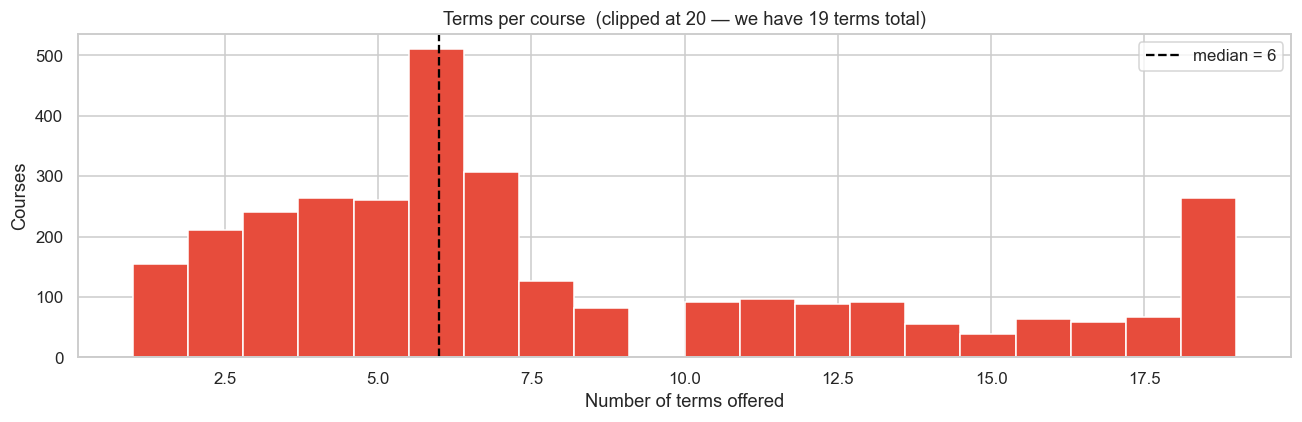

Courses appearing in 3 or fewer terms: 607  (19.8%)
NOTE: historical features will be weak/null for these courses


In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
terms_per_course.clip(upper=20).hist(bins=20, ax=ax, color='#e74c3c', edgecolor='white')
ax.axvline(terms_per_course.median(), color='black', linestyle='--', linewidth=1.5,
           label=f'median = {terms_per_course.median():.0f}')
ax.set_title('Terms per course  (clipped at 20 — we have 19 terms total)')
ax.set_xlabel('Number of terms offered')
ax.set_ylabel('Courses')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH / '07_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

sparse = (terms_per_course <= 3).sum()
print(f'Courses appearing in 3 or fewer terms: {sparse:,}  ({sparse/len(terms_per_course)*100:.1f}%)')
print('NOTE: historical features will be weak/null for these courses')

In [18]:
# same-semester consistency — does a course offered in fall tend to come back next fall?
# compute per course per term_order: how many times was it offered?
semester_freq = (
    course_term.groupby(['ml_course_id', 'term_order'])
    .size()
    .reset_index(name='times_offered_this_semester')
)

print('Times offered in same semester — distribution:')
print(semester_freq['times_offered_this_semester'].describe().round(1))
print()

# courses offered in all 6+ instances of a given semester (very consistent)
# we have ~6-7 fall/spring/summer terms in our window
consistent = (semester_freq['times_offered_this_semester'] >= 5).sum()
print(f'course+semester combos offered 5+ times: {consistent:,}  ({consistent/len(semester_freq)*100:.1f}%)')
print('These will have strong same_semester_offer_ratio signal')

Times offered in same semester — distribution:
count   6153.000
mean       4.000
std        2.100
min        1.000
25%        2.000
50%        4.000
75%        6.000
max        7.000
Name: times_offered_this_semester, dtype: float64

course+semester combos offered 5+ times: 2,793  (45.4%)
These will have strong same_semester_offer_ratio signal


---
## Block 5 — Temporal patterns

In [19]:
# COVID effect on capacity and enrollment
covid_comp = df.groupby('is_covid_affected')[['capacity', 'enrolled', 'fill_rate']].agg(['mean', 'median']).round(2)
print('COVID vs non-COVID:')
print(covid_comp)

COVID vs non-COVID:
                  capacity        enrolled        fill_rate       
                      mean median     mean median      mean median
is_covid_affected                                                 
0                   49.780 30.000   35.590 17.000     0.670  0.730
1                   52.320 33.000   38.480 21.000     0.680  0.760


      capacity  enrolled  fill_rate
year                               
2020    32.000    21.000      0.770
2021    34.000    20.000      0.740
2022    30.000    19.000      0.730
2023    30.000    18.000      0.720
2024    30.000    17.000      0.730
2025    27.000    16.000      0.740
2026    30.000    18.000      0.770


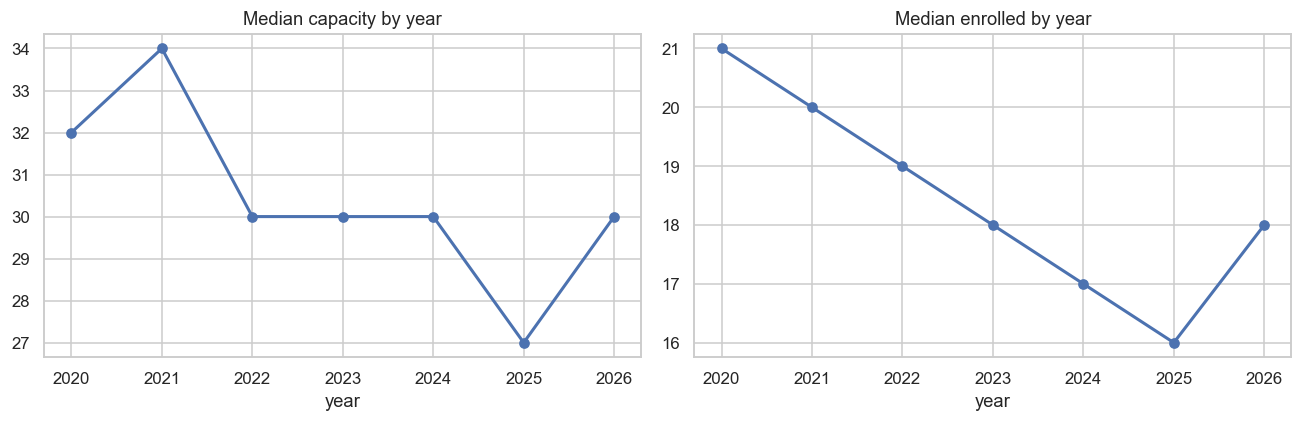

In [20]:
# year-over-year median capacity and enrollment trends
yearly = df.groupby('year')[['capacity', 'enrolled', 'fill_rate']].median().round(2)
print(yearly)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['capacity', 'enrolled']):
    yearly[col].plot(ax=ax, marker='o', linewidth=2)
    ax.set_title(f'Median {col} by year')
    ax.set_xlabel('year')
plt.tight_layout()
plt.savefig(FIG_PATH / '08_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

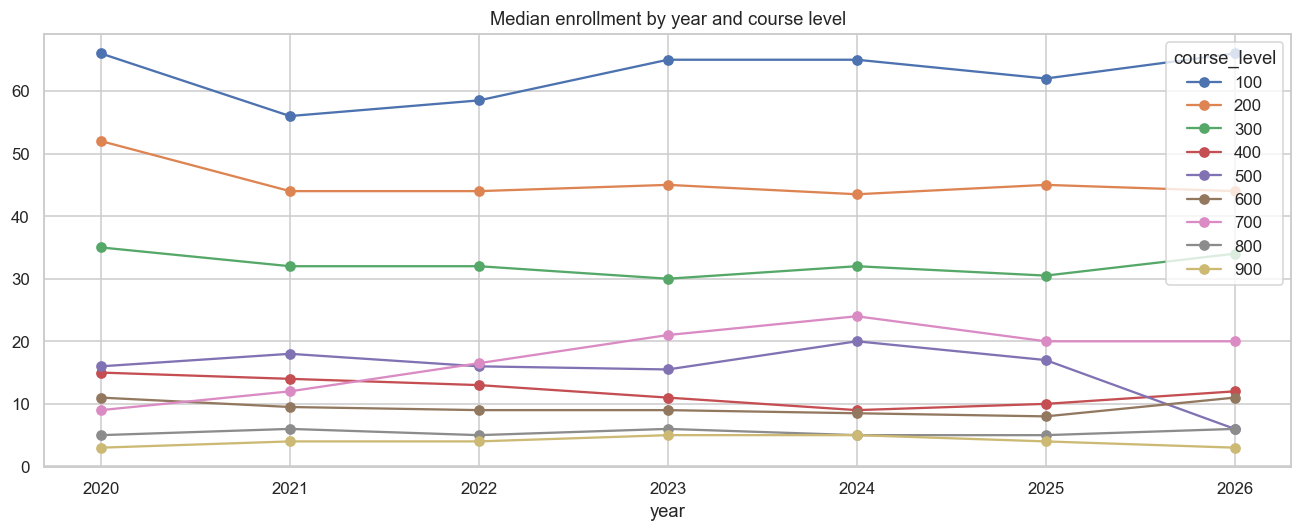

In [21]:
# do capacity/enrollment trends differ by course level over time?
# if so, course_level × year interaction might matter
level_year = df.groupby(['year', 'course_level'])['enrolled'].median().unstack()
fig, ax = plt.subplots(figsize=(12, 5))
level_year.plot(ax=ax, marker='o')
ax.set_title('Median enrollment by year and course level')
ax.set_xlabel('year')
ax.legend(title='course_level')
plt.tight_layout()
plt.savefig(FIG_PATH / '09_level_year_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 6 — Categorical encoding check

`dept_code` and `degree_level` are categorical features used in all three models.  
High cardinality in `dept_code` determines whether we use label encoding or target encoding.

In [22]:
# dept_code cardinality
n_depts = df['dept_code'].nunique()
dept_counts = df['dept_code'].value_counts()

print(f'unique dept_codes: {n_depts}')
print()
print('Top 20:')
print(dept_counts.head(20))
print()
rare = (dept_counts < 50).sum()
print(f'Departments with < 50 sections: {rare}  ({rare/n_depts*100:.1f}%)')
print('NOTE: if > 20 unique depts, use target encoding or label encoding — not one-hot')

unique dept_codes: 72

Top 20:
dept_code
BUS     3945
EDUC    2458
CMPT    2138
HSCI    1361
PSYC    1191
CA      1110
IAT     1032
CMNS     993
CRIM     965
BISC     955
ENSC     845
MBB      838
BPK      803
MATH     801
CHEM     778
ECON     775
INLG     769
MSE      703
LING     689
HIST     654
Name: count, dtype: int64

Departments with < 50 sections: 16  (22.2%)
NOTE: if > 20 unique depts, use target encoding or label encoding — not one-hot


In [23]:
# degree_level — how many unique values?
print('degree_level value counts:')
print(df['degree_level'].value_counts(dropna=False))
print()
print('degree_level vs capacity and enrolled:')
print(df.groupby('degree_level')[['capacity', 'enrolled']].median().round(1))

degree_level value counts:
degree_level
UGRD    23657
GRAD    10002
Name: count, dtype: int64

degree_level vs capacity and enrolled:
              capacity  enrolled
degree_level                    
GRAD            16.000     6.000
UGRD            35.000    28.000


In [24]:
# ml_course_id cardinality — used as a feature in all models
# Random Forest can handle high-cardinality integer IDs but check how many unique courses
n_courses = df['ml_course_id'].nunique()
print(f'unique ml_course_id values: {n_courses}')
print('NOTE: ml_course_id is used as a label-encoded integer — no transformation needed')

unique ml_course_id values: 3067
NOTE: ml_course_id is used as a label-encoded integer — no transformation needed


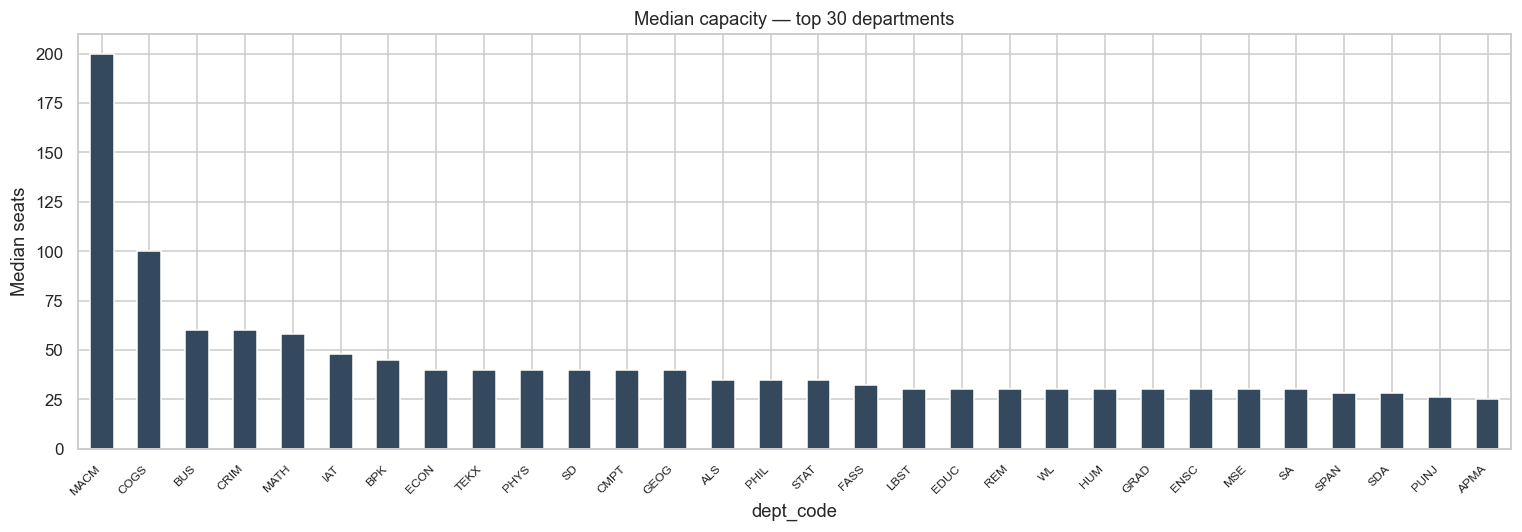

Median capacity range across departments: 5 – 200
Wide range = dept_code carries signal


In [25]:
# dept_code mean capacity — does it vary meaningfully across departments?
# validates dept_code as a useful feature
dept_cap = df.groupby('dept_code')['capacity'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
dept_cap.head(30).plot(kind='bar', ax=ax, color='#34495e', edgecolor='white')
ax.set_title('Median capacity — top 30 departments')
ax.set_xlabel('dept_code')
ax.set_ylabel('Median seats')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_PATH / '10_dept_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median capacity range across departments: {dept_cap.min():.0f} – {dept_cap.max():.0f}')
print('Wide range = dept_code carries signal')

---
## Block 7 — EDA summary

Fill this in after running all blocks above. Record findings that affect feature engineering decisions.

In [26]:
# final summary of figures saved
for f in sorted(FIG_PATH.glob('*.png')):
    print(f.name)

01_sections_per_term.png
02_target_distributions.png
03_course_level_signal.png
04_units_signal.png
05_seasonality.png
06_correlation_heatmap.png
07_sparsity.png
08_yearly_trends.png
09_level_year_trends.png
10_dept_capacity.png
